#**Carga de altura y peso, usando los datos cargados en clases**

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

#datos de altura y pesos
datos = [[1.79,74],
[1.61,55],
[1.8,72],
[1.82,84],
[1.61,56],
[1.74,67]
[1.75,65],
[1.8,80],
[1.67,76.4],
[1.6,60],
[1.82,90],
[1.74,68.5],
[1.67,78.1],
[1.63,59],
[1.78,63],
[1.56,60],
[1.63,89],
[1.83,95],
[1.66,66],
[1.83,67],
[1.6,69],
[1.62,57],
[1.75,70],
[1.75,75],
[1.9,100],
[1.72,60],
[1.7,75],
[1.55,45],
[1.5,75],
[1.75,80],
[1.81,80],
[1.8,73],
[1.65,67],
[1.73,55],
[1.8,90],
[1.56,58],
[1.5,60],
[1.7,50],
[1.9,95],
[1.7,70],
[1.28,56],
[1.65,63],
[1.74,65],
[1.92,60],
[1.95,90],]

In [38]:
# Crear matriz de datos
X = np.array(datos, dtype=float)

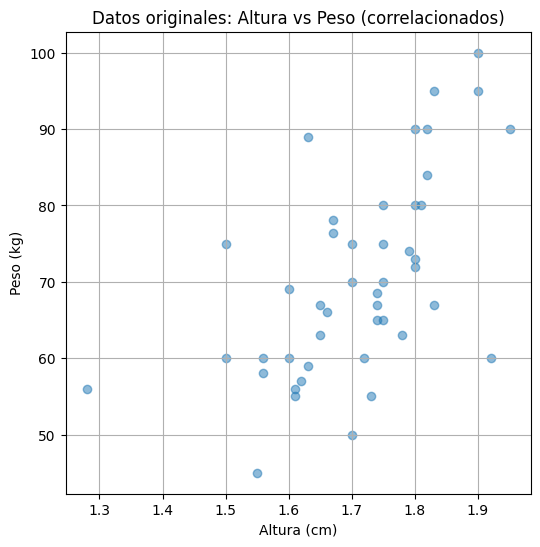

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")
plt.title("Datos originales: Altura vs Peso (correlacionados)")
plt.grid(True)
plt.show()

####**Calcular el coeficiente de correlación de Pearson entre las dos variables altura y peso**

0.5868901027173232


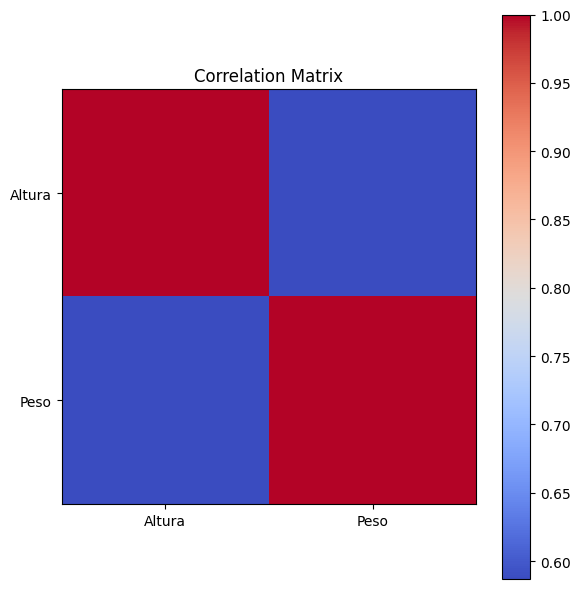

<Axes: >

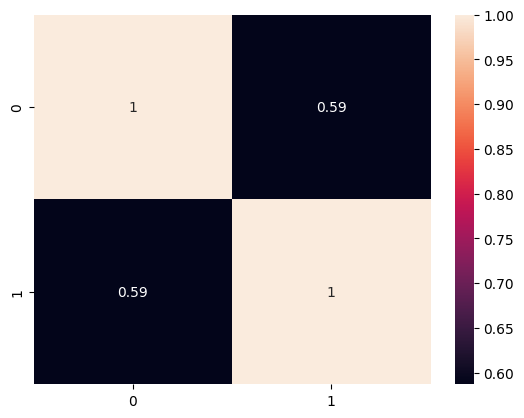

In [66]:
corr, p = np.corrcoef(X.T)
print(corr[1])

plt.figure(figsize=(6,6))
plt.imshow(np.corrcoef(X.T), cmap='coolwarm', interpolation='nearest')
plt.colorbar()
#agregar valores de correlación en el gráfico
plt.title("Correlation Matrix") # Added a title for clarity
plt.xticks([0, 1], ['Altura', 'Peso']) # Added labels for x-axis
plt.yticks([0, 1], ['Altura', 'Peso']) # Added labels for y-axis
plt.show() # Added plt.show() to display the plot


import seaborn as sns
sns.heatmap(np.corrcoef(X.T), annot=True)

####**Centrar los datos**

In [15]:
medias = X.mean(axis=0)
Xc = X - medias
print("\nMedias:", medias)
#print("Datos centrados:\n", Xc)


Medias: [ 1.686      70.28888889]


####**Matriz de covarianza**


Matriz de covarianza Σ:
 [[1.61831313e-02 9.68820707e-01]
 [9.68820707e-01 1.68387828e+02]]


<Axes: >

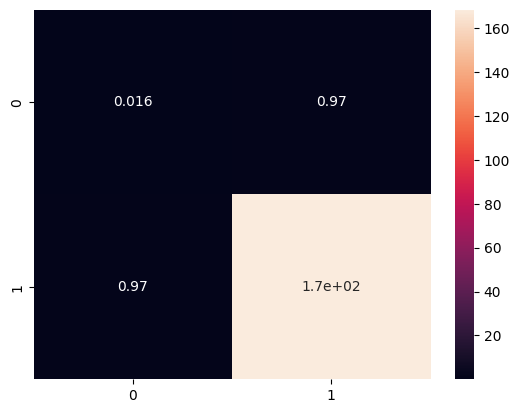

In [68]:
Sigma = np.cov(X, rowvar=False, bias=False) #rowvar=False: cada columna es una variable, y las filas son observaciones.  bias=False (por defecto): divide por 𝑁−1 N−1 → covarianza muestral.
print("\nMatriz de covarianza Σ:\n", Sigma)

sns.heatmap(Sigma, annot=True)

####**Calcular determinante de (Σ - λI) (expansión manual para 2x2)**

In [17]:
a, b, c, d = Sigma[0,0], Sigma[0,1], Sigma[1,0], Sigma[1,1]

####**Ecuación característica: λ² - (a+d)λ + (ad - bc) = 0**

In [18]:
coef = [1, -(a+d), a*d - b*c]
print("\nEcuación característica: λ² - (a+d)λ + (ad - bc) = 0")
print("Coeficientes:", coef)


Ecuación característica: λ² - (a+d)λ + (ad - bc) = 0
Coeficientes: [1, np.float64(-168.4456982828283), np.float64(8.071284981714875)]


####**Resolver la ecuación cuadrática**


In [19]:
lambdas = np.roots(coef)
print("\nValores propios (λ):", lambdas)


Valores propios (λ): [1.68397768e+02 4.79298809e-02]


####**Calcular vectores propios**

In [22]:
eigvals, eigvecs = np.linalg.eig(Sigma)
print("\nAutovalores con numpy:\n", eigvals)
print("\nAutovectores (columnas):\n", eigvecs)


Autovalores con numpy:
 [4.79298809e-02 1.68397768e+02]

Autovectores (columnas):
 [[-0.99997048 -0.00768404]
 [ 0.00768404 -0.99997048]]


####**Verificar Σv = λv**

In [23]:
for i in range(len(eigvals)):
    v = eigvecs[:, i]
    lhs = Sigma @ v
    rhs = eigvals[i] * v
    print(f"\nChequeo λ{i+1}: Σv ≈ λv")
    print("Σv =", lhs)
    print("λv =", rhs)


Chequeo λ1: Σv ≈ λv
Σv = [-0.04792847  0.00036829]
λv = [-0.04792847  0.00036829]

Chequeo λ2: Σv ≈ λv
Σv = [  -1.29397467 -168.39279685]
λv = [  -1.29397467 -168.39279685]


####**Varianza explicada por autovalores**

In [28]:
exp_var = eigvals / eigvals.sum()

# Varianza explicada
var_exp = eigvals / eigvals.sum()

# Varianza explicada acumulada
var_exp_cum = np.cumsum(var_exp)

print("Varianza explicada por cada componente:", var_exp)
print("Varianza explicada (%) :", var_exp * 100)
print("Varianza acumulada (%) :", var_exp_cum * 100)

Varianza explicada por cada componente: [2.84542030e-04 9.99715458e-01]
Varianza explicada (%) : [2.84542030e-02 9.99715458e+01]
Varianza acumulada (%) : [2.8454203e-02 1.0000000e+02]


####**Obtener datos proyectados**

In [32]:
#ordenar los vectores propios, para dejar hacia la izquierda las componentes que mejor describen los datos
eigvecsSorted = eigvecs[:, np.argsort(eigvals)[::-1]]
print("\nAutovectores ordenados:", eigvecsSorted)

Xpca = Xc @ eigvecsSorted
print("\nDatos proyectados en los componentes principales:\n", Xpca)


Autovectores ordenados: [[-0.00768404 -0.99997048]
 [-0.99997048  0.00768404]]

Datos proyectados en los componentes principales:
 [[-3.71180069e+00 -7.54806149e-02]
 [ 1.52890215e+01 -4.14826302e-02]
 [-1.71193657e+00 -1.00848393e-01]
 [-1.37117360e+01 -2.86393601e-02]
 [ 1.42890510e+01 -3.37985933e-02]
 [ 3.28837685e+00 -7.92703494e-02]
 [ 5.28824097e+00 -1.04638128e-01]
 [-9.71170039e+00 -3.93760982e-02]
 [-6.11080775e+00  6.29575310e-02]
 [ 1.02892460e+01  6.93725910e-03]
 [-1.97115588e+01  1.74648613e-02]
 [ 1.78842114e+00 -6.77442940e-02]
 [-7.81075756e+00  7.60203937e-02]
 [ 1.12889859e+01 -3.07458921e-02]
 [ 7.28795140e+00 -1.50005316e-01]
 [ 1.02895533e+01  4.69360782e-02]
 [-1.87101284e+01  1.99775215e-01]
 [-2.47114881e+01  4.58853411e-02]
 [ 4.28896205e+00 -6.95674810e-03]
 [ 3.28768529e+00 -1.69267692e-01]
 [ 1.28951166e+00  7.60935913e-02]
 [ 1.32890037e+01 -3.61142612e-02]
 [ 2.88388582e-01 -6.62179434e-02]
 [-4.71146381e+00 -2.77977589e-02]
 [-2.97118783e+01  1.4307592

#**Usando paquete de Scikit-learn para aplicar PCA**

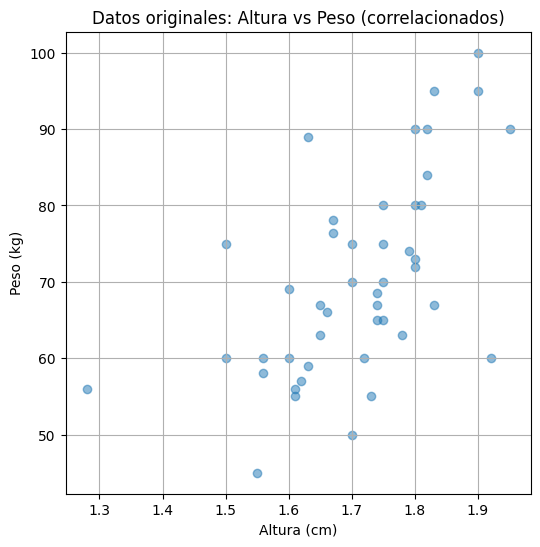

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

X = np.array(datos, dtype=float)

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")
plt.title("Datos originales: Altura vs Peso (correlacionados)")
plt.grid(True)
plt.show()

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print("Suma:", np.sum(pca.explained_variance_ratio_))
print("X_pca: ", X_pca)

Varianza explicada por cada componente: [0.79344505 0.20655495]
Suma: 1.0
X_pca:  [[ 6.64203638e-01  2.55184597e-01]
 [-1.39466285e+00  2.90397631e-01]
 [ 6.10201523e-01  4.21611905e-01]
 [ 1.38391498e+00 -1.27251173e-01]
 [-1.33955549e+00  2.35290275e-01]
 [-2.61083199e-03  3.59873108e-01]
 [-5.66129477e-02  5.26300416e-01]
 [ 1.05106037e+00 -1.92469414e-02]
 [ 1.21910141e-01 -5.51624208e-01]
 [-1.17533867e+00 -4.13517441e-02]
 [ 1.71455912e+00 -4.57895308e-01]
 [ 8.00502017e-02  2.77212075e-01]
 [ 2.15592646e-01 -6.45306713e-01]
 [-1.06180823e+00  1.82393399e-01]
 [ 1.81012855e-03  8.05152915e-01]
 [-1.40018905e+00 -2.66202128e-01]
 [ 5.91412440e-01 -1.47082727e+00]
 [ 2.04630849e+00 -6.77219491e-01]
 [-5.07418955e-01 -3.47203033e-02]
 [ 5.03302531e-01  8.65786472e-01]
 [-6.79372463e-01 -5.37317946e-01]
 [-1.22823554e+00  2.36395515e-01]
 [ 2.18923831e-01  2.50763637e-01]
 [ 4.94460610e-01 -2.47731421e-02]
 [ 2.71533344e+00 -5.59268098e-01]
 [-5.00787514e-01  6.33199407e-01]
 [ 2.133

pca.explained_variance_, components, varianza acumulada:  [1.62295579 0.42249876] [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]] [0.79344505 1.        ]
varianza explicada, componentes:  1.6229557868699893 [0.70710678 0.70710678]
varianza explicada, componentes:  0.42249875858455566 [ 0.70710678 -0.70710678]


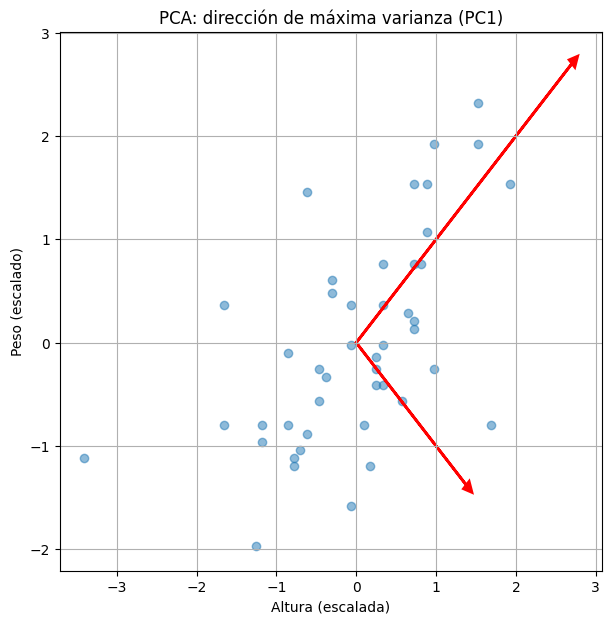

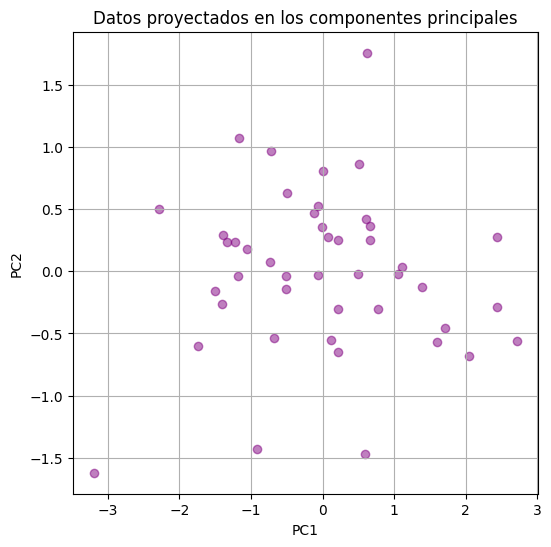

In [45]:
components = pca.components_
means = np.mean(X_scaled, axis=0)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
print("pca.explained_variance_, components, varianza acumulada: ", pca.explained_variance_, components, varianza_acumulada)

plt.figure(figsize=(7,7))
plt.scatter(X_scaled[:,0], X_scaled[:,1], alpha=0.5)
plt.title("PCA: dirección de máxima varianza (PC1)")
plt.xlabel("Altura (escalada)")
plt.ylabel("Peso (escalado)")

# Dibujar vectores de componentes
for length, vector in zip(pca.explained_variance_, components):
    print("varianza explicada, componentes: ", length, vector)
    v = vector * 3 * np.sqrt(length)
    plt.arrow(means[0], means[1], v[0], v[1],
              head_width=0.1, head_length=0.1, linewidth=2, color="red")

plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5, c="purple")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Datos proyectados en los componentes principales")
plt.grid(True)
plt.show()